# 0 - EDA (Visualisation des données, remise en contexte)

Via l'EDA on pourrait voir que :
- "age" a 50 valeurs aberrantes (age > 500 ans)
- "cholesterol" est fortement corrélé avec la target (r=0.82)
- "profession = Boulanger" → risque moyen 2x plus élevé
- "vitamin_D" a 30% de valeurs manquantes

Donc on pourra ajuster le preprocessing en conséquence
```python
def preprocess(X):
    X = remove_outliers(X, 'age', threshold=200)  # Grâce à l'EDA
    X = impute_missing(X, 'vitamin_D', strategy='median')  # Grâce à l'EDA
    # ...
```

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme()   # active le style seaborn pour matplotlib
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, LabelEncoder

import matplotlib.pyplot as plt

## 1. Structure des données
Combien de schtroumpf ? combien de feature ? quel type de données ? valeurs manquantes ? doublons ? 

In [26]:
X_train = pd.read_csv('../data/data_labeled/X_train.csv')
y_train = pd.read_csv('../data/data_labeled/y_train.csv')
X_test = pd.read_csv('../data/data_labeled/X_test.csv')
y_test = pd.read_csv('../data/data_labeled/y_test.csv')
X_unlabeled = pd.read_csv('../data/data_unlabeled/X.csv')

print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape X_test: {X_test.shape}")
print(f"Shape y_test: {y_test.shape}")
print(f"Shape X_unlabeled: {X_unlabeled.shape}")

Shape X_train: (1000, 14)
Shape y_train: (999, 1)
Shape X_test: (500, 14)
Shape y_test: (499, 1)
Shape X_unlabeled: (500, 14)


**Visualisations:**

In [27]:
print("\nValeurs manquantes:")
print(X_train.isnull().sum())

X_train.describe()


Valeurs manquantes:
age                  0
blood pressure       0
calcium              0
cholesterol          0
hemoglobin           0
height               0
potassium            0
profession           0
sarsaparilla         0
smurfberry liquor    0
smurfin donuts       0
vitamin D            0
weight               0
img_filename         0
dtype: int64


,age,blood pressure,calcium,cholesterol,hemoglobin,height,potassium,vitamin D,weight
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,117.611000,108.402300,2.445580,111.997520,14.214560,7.59766,4.313280,30.173120,105.406230
std,30.169585,11.035291,0.205762,22.016259,2.051817,0.39668,0.505503,4.998889,16.907572
min,20.000000,84.930000,1.740000,45.680000,6.360000,6.39000,2.750000,14.340000,58.800000
25%,98.000000,100.765000,2.310000,97.427500,12.767500,7.32000,3.970000,27.097500,93.350000
50%,118.000000,106.085000,2.445000,110.980000,14.255000,7.59000,4.320000,30.285000,104.235000
75%,138.000000,114.017500,2.590000,126.107500,15.630000,7.86000,4.652500,33.315000,115.942500
max,180.000000,154.540000,3.100000,187.190000,20.880000,8.86000,5.850000,47.060000,160.400000


## 2. Quel target ?

### Questions
- Quelle est la distribution du risque cardiaque ?
- La distribution est-elle normale ? Skewed ? 
- Quel est le range des valeurs ?
- Y a-t-il d'extreme genre "outliers" ?

### Réponses
- 
- Visiblement pas normale, elle est plus *right skewed*
- [0, 0.6[
- 2-3 personnes à 0.5 mais pas outliers je pense

<Figure size 1000x600 with 0 Axes>

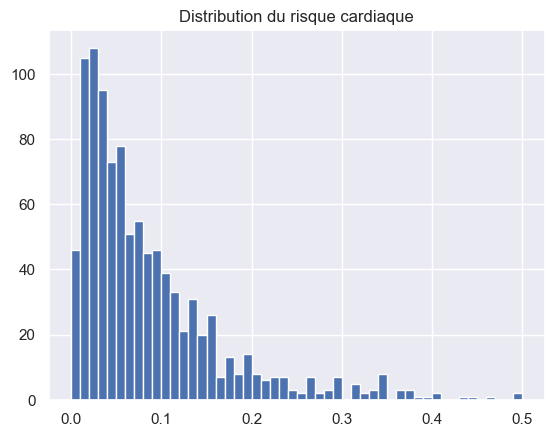

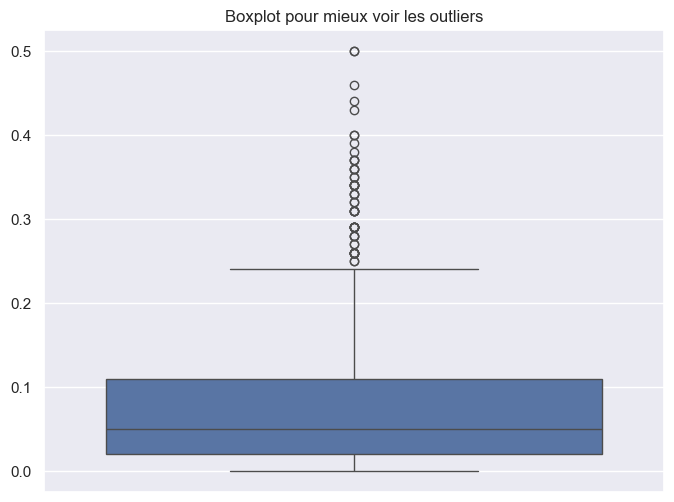

In [28]:
plt.figure(figsize=(10, 6))
y_train.hist(bins= 50)
plt.title('Distribution du risque cardiaque')

plt.figure(figsize=(8, 6))
sns.boxplot(y=y_train.values.flatten())
plt.title('Boxplot pour mieux voir les outliers')
plt.show()

## 3. Feature numérique
### Questions
- Quelles features ont des outliers (donnée aberrante) ?
- Y a-t-il des corrélations entre features ? 
- Quelle feature est la plus corrélée avec la target (le risque de faire un arret cardiaque) ?
- Y a-t-il de la multicolinéarité ? (2 features trop similaires)
- Features à supprimer ?

### Réponses

- Je sais pas ?
- Oui, il y a des corrélations entre weight et height, cholesterol et blood pressure, blood press et weight, weight et cholesterol
- Vitamine D: Plus de vitamine D -> Moins de risque (corrélation négative) (je pensais que ca allait etre le cholesterol mais au final peut-etre que c'est pas une correlation lineaire (on verra dans l'analyse non lineaire))
- - weight <-> height : r=0.33 (à surveiller)
  - cholesterol <-> blood_pressure : r=0.48 (pareil)
  - cholesterol <-> weight : r = 0.33 (pareil) 
  - → Peut-être créer un BMI au lieu de garder weight + height
- 'hemoglobin', 'calcium', 'cholesterol' ? par intuition je retirerais pas le cholesterol mais bon jsp

vitamin D        -0.051816
height            0.047352
weight           -0.041593
age               0.028062
blood pressure   -0.025056
potassium         0.012078
hemoglobin       -0.003509
calcium          -0.003249
cholesterol      -0.001169
Name: target, dtype: float64
<bound method Series.max of vitamin D        -0.051816
height            0.047352
weight           -0.041593
age               0.028062
blood pressure   -0.025056
potassium         0.012078
hemoglobin       -0.003509
calcium          -0.003249
cholesterol      -0.001169
Name: target, dtype: float64>
Features faiblement corrélées (|r| < 0.01) : ['hemoglobin', 'calcium', 'cholesterol']

Top 6 features les plus corrélées : ['vitamin D', 'height', 'weight', 'age', 'blood pressure', 'potassium', 'hemoglobin', 'calcium', 'cholesterol']


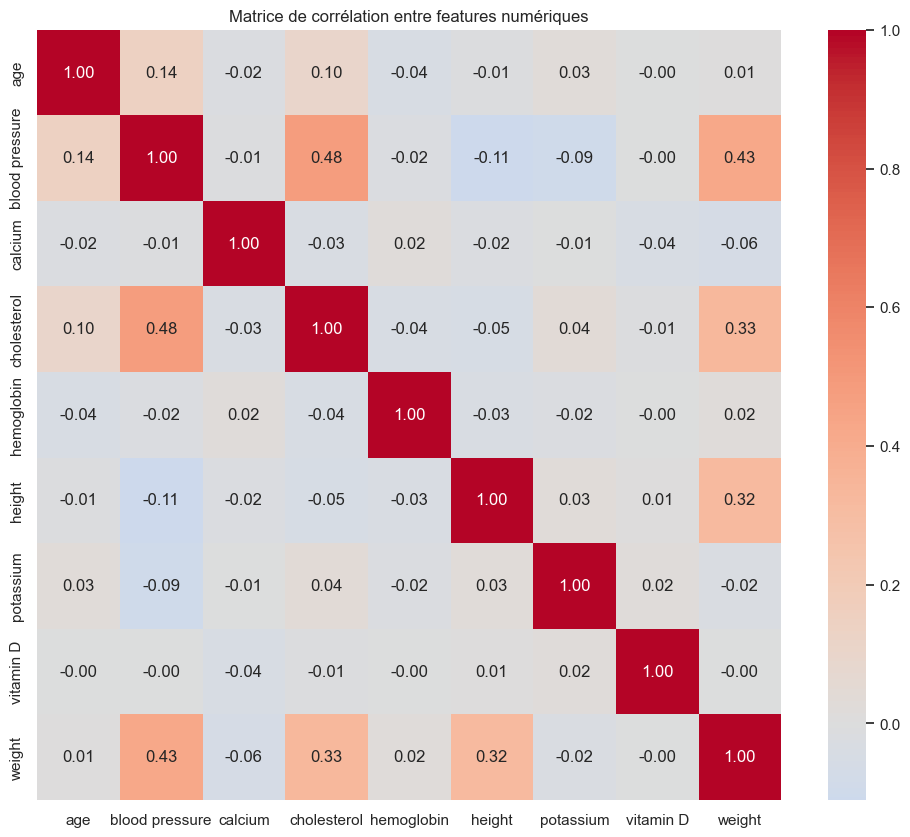

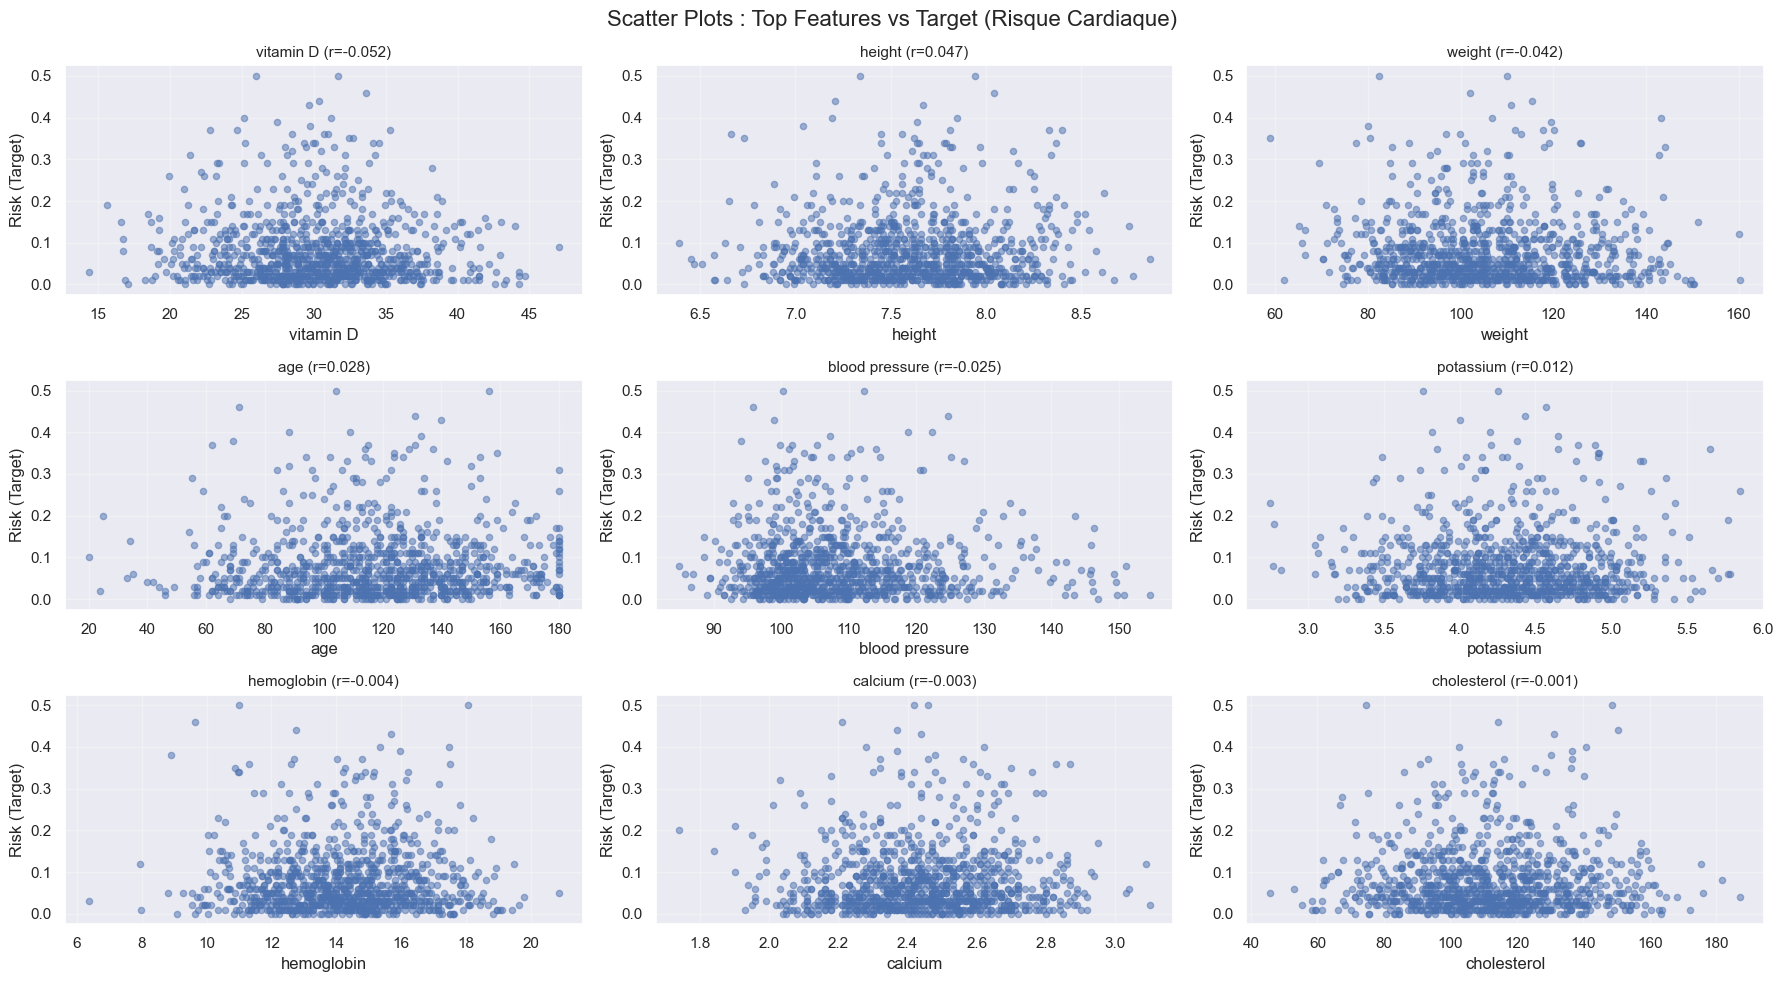

Variables avec multicolinéarité sévère (VIF > 10):


,Variable,VIF


In [ ]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = X_train[numeric_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matrice de corrélation entre features numériques')

X_train_with_target = X_train.copy()
X_train_with_target['target'] = y_train
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
correlations_with_target = X_train_with_target[numeric_features + ['target']].corr()['target']
correlations_with_target = correlations_with_target.drop('target') # Pas avoir la correlation avec elle meme 
correlations_with_target = correlations_with_target.sort_values(key=abs, ascending=False)

print(correlations_with_target)
print(correlations_with_target.max)
print(f"Features faiblement corrélées (|r| < 0.01) : {correlations_with_target[abs(correlations_with_target) < 0.01].index.tolist()}\n")
# Sélectionner les 6 features les plus corrélées
top_features = correlations_with_target.head(9).index.tolist()
print(f"Top 6 features les plus corrélées : {top_features}")

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
fig.suptitle('Scatter Plots : Top Features vs Target (Risque Cardiaque)', fontsize=16)
for i, feature in enumerate(top_features):
    ax = axes[i//3, i%3]
    
    # pcq il y a une différence de longueur
    n = min(len(X_train), len(y_train))
    ax.scatter(X_train[feature].iloc[:n], y_train.iloc[:n].squeeze(), alpha=0.5, s=20)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Risk (Target)', fontsize=12)
    
    corr_value = correlations_with_target[feature]  
    ax.set_title(f'{feature} (r={corr_value:.3f})', fontsize=11)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Multicolinéarité
X_vif_test = X_train[numeric_features].copy()
vif_data = pd.DataFrame()
vif_data["Variables"] = X_vif_test.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_test.values,i) for i in range(X_vif_test.shape[1])]
print(vif_data)

### Comparaison choléstérol et vitamine d

In [30]:
"""
print(f"Target shape {y_train.shape}")
print(f"Cholesterol shape {X_train['cholesterol'].shape}")

# scatter plots côte à côte pour comparer
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Cholesterol vs Target
ax1 = axes[0]
n = min(len(X_train), len(y_train))
scatter1 = ax1.scatter(X_train['cholesterol'].iloc[:n], y_train.iloc[:n], 
                       c=y_train, cmap='RdYlBu_r', alpha=0.6, s=10)
ax1.set_xlabel('Cholesterol', fontsize=13)
ax1.set_ylabel('Risque Cardiaque', fontsize=13)
ax1.set_title(f'Cholesterol vs Target\n(r = {correlations_with_target["cholesterol"]:+.3f})', 
              fontsize=14, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Risque')

# Vitamin_D vs Target
ax2 = axes[1]
scatter2 = ax2.scatter(X_train['vitamin D'].iloc[:n], y_train.iloc[:n], 
                       c=y_train, cmap='RdYlBu_r', alpha=0.6, s=10)
ax2.set_xlabel('Vitamin D', fontsize=13)
ax2.set_ylabel('Risque Cardiaque', fontsize=13)
ax2.set_title(f'Vitamin D vs Target\n(r = {correlations_with_target["vitamin D"]:+.3f})', 
              fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='Risque')

plt.tight_layout()
plt.show()
"""

'\nprint(f"Target shape {y_train.shape}")\nprint(f"Cholesterol shape {X_train[\'cholesterol\'].shape}")\n\n# scatter plots côte à côte pour comparer\nfig, axes = plt.subplots(1, 2, figsize=(16, 6))\n# Cholesterol vs Target\nax1 = axes[0]\nn = min(len(X_train), len(y_train))\nscatter1 = ax1.scatter(X_train[\'cholesterol\'].iloc[:n], y_train.iloc[:n], \n                       c=y_train, cmap=\'RdYlBu_r\', alpha=0.6, s=10)\nax1.set_xlabel(\'Cholesterol\', fontsize=13)\nax1.set_ylabel(\'Risque Cardiaque\', fontsize=13)\nax1.set_title(f\'Cholesterol vs Target\n(r = {correlations_with_target["cholesterol"]:+.3f})\', \n              fontsize=14, fontweight=\'bold\')\nplt.colorbar(scatter1, ax=ax1, label=\'Risque\')\n\n# Vitamin_D vs Target\nax2 = axes[1]\nscatter2 = ax2.scatter(X_train[\'vitamin D\'].iloc[:n], y_train.iloc[:n], \n                       c=y_train, cmap=\'RdYlBu_r\', alpha=0.6, s=10)\nax2.set_xlabel(\'Vitamin D\', fontsize=13)\nax2.set_ylabel(\'Risque Cardiaque\', fontsize=13)\

## 4. Analyse categorical feature

### Questions :
- Combien de catégories dans "profession" ?
- Y a-t-il des catégories rares (< 1% des données) ?
- Quel impact sur la target ?

### Réponses :
- 6 catégories de professions
- Smallest est à 8% donc ok
- Elles sont toutes proches en moyenne de ~0.07/0.08 donc la profession n'a quasi aucun impact -> one hot incoding. On mentionnera dans le rapport que via l'EDA on a vu que la profession avait un impact négligeable

Pourcentage of the smallest : administration and governance -> 0.08


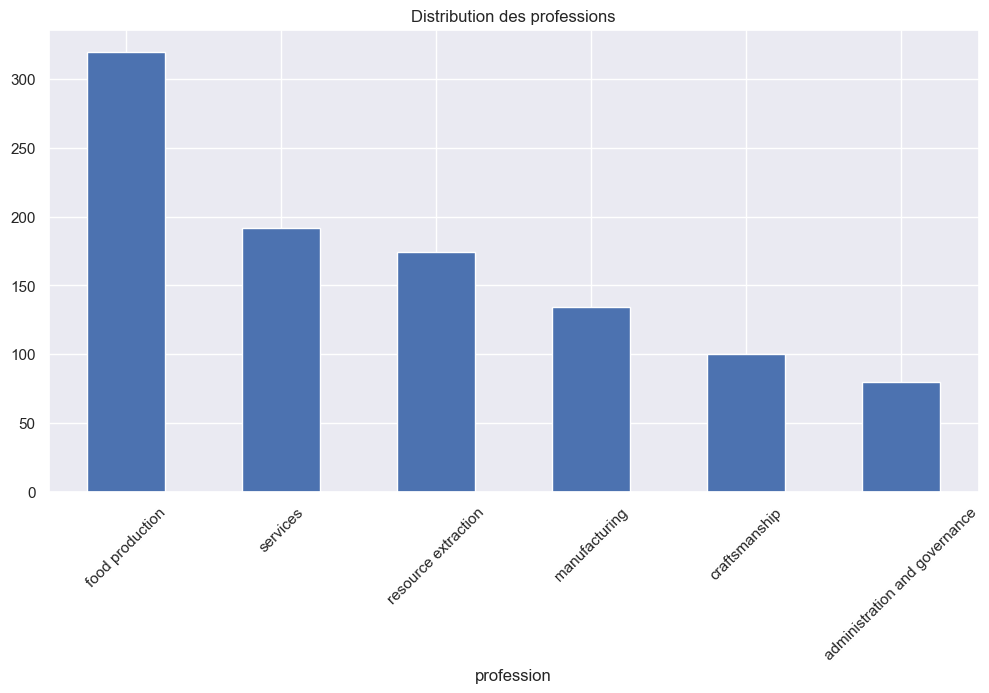

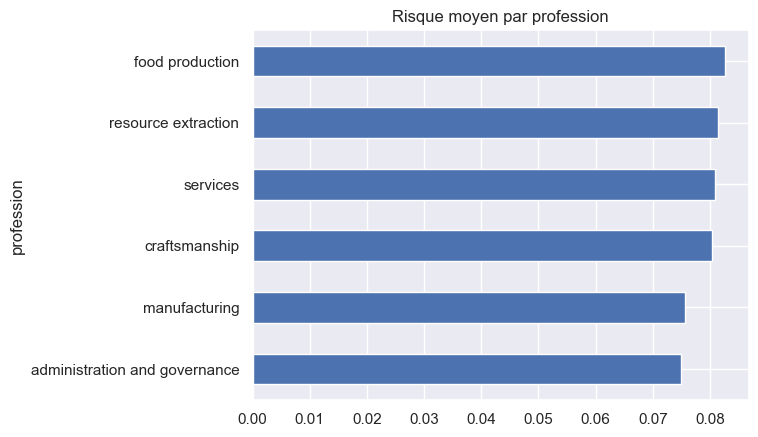

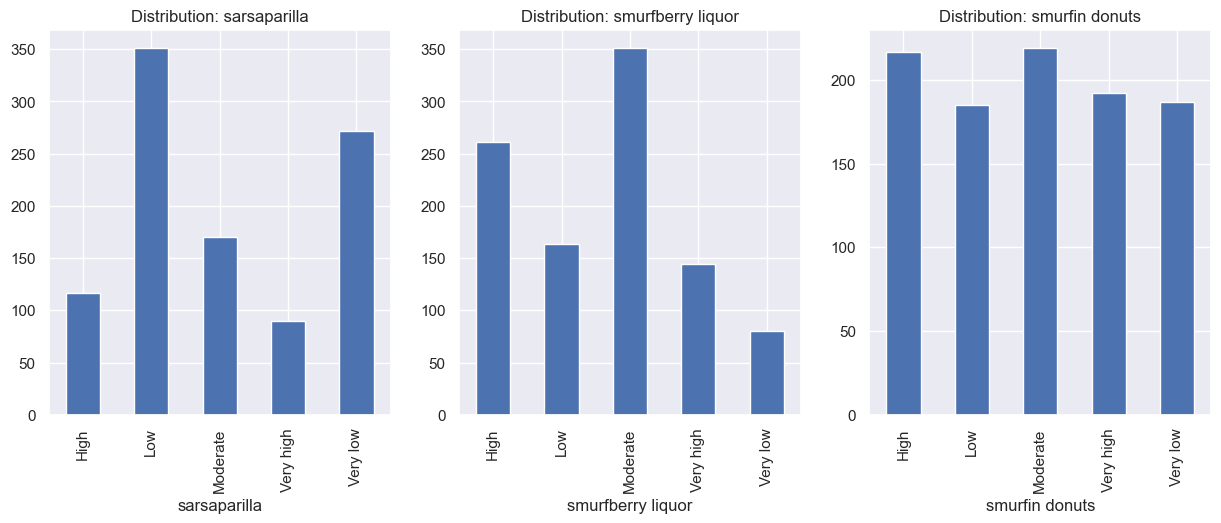

In [31]:
smallest_pourcentage = X_train['profession'].value_counts().min()/X_train['profession'].value_counts().sum()
smallest = X_train['profession'].min()
print(f"Pourcentage of the smallest : {smallest} -> {smallest_pourcentage}")

plt.figure(figsize=(12,6))
X_train['profession'].value_counts().plot(kind='bar')
plt.title('Distribution des professions')
plt.xticks(rotation=45)
plt.show()

risk_by_profession = X_train.copy()
risk_by_profession['target'] = y_train
risk_by_profession.groupby('profession')['target'].mean().sort_values().plot(kind='barh')
plt.title('Risque moyen par profession')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ordinal_features = ['sarsaparilla', 'smurfberry liquor', 'smurfin donuts']
for i, feature in enumerate(ordinal_features):
    X_train[feature].value_counts().sort_index().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribution: {feature}')
plt.show()


## 5. Anomalies
### Questions 
- Y a-t-il des valeurs impossibles ? (âge négatif, poids = 0)
- Y a-t-il des valeurs manquantes ?
- Faut il supprimer certains outliers ? 

### Réponses 
- Non
- Non
- Peut-être dans `blood-pressure`

Valeurs manquantes : 
age                  0
blood pressure       0
calcium              0
cholesterol          0
hemoglobin           0
height               0
potassium            0
profession           0
sarsaparilla         0
smurfberry liquor    0
smurfin donuts       0
vitamin D            0
weight               0
img_filename         0
dtype: int64


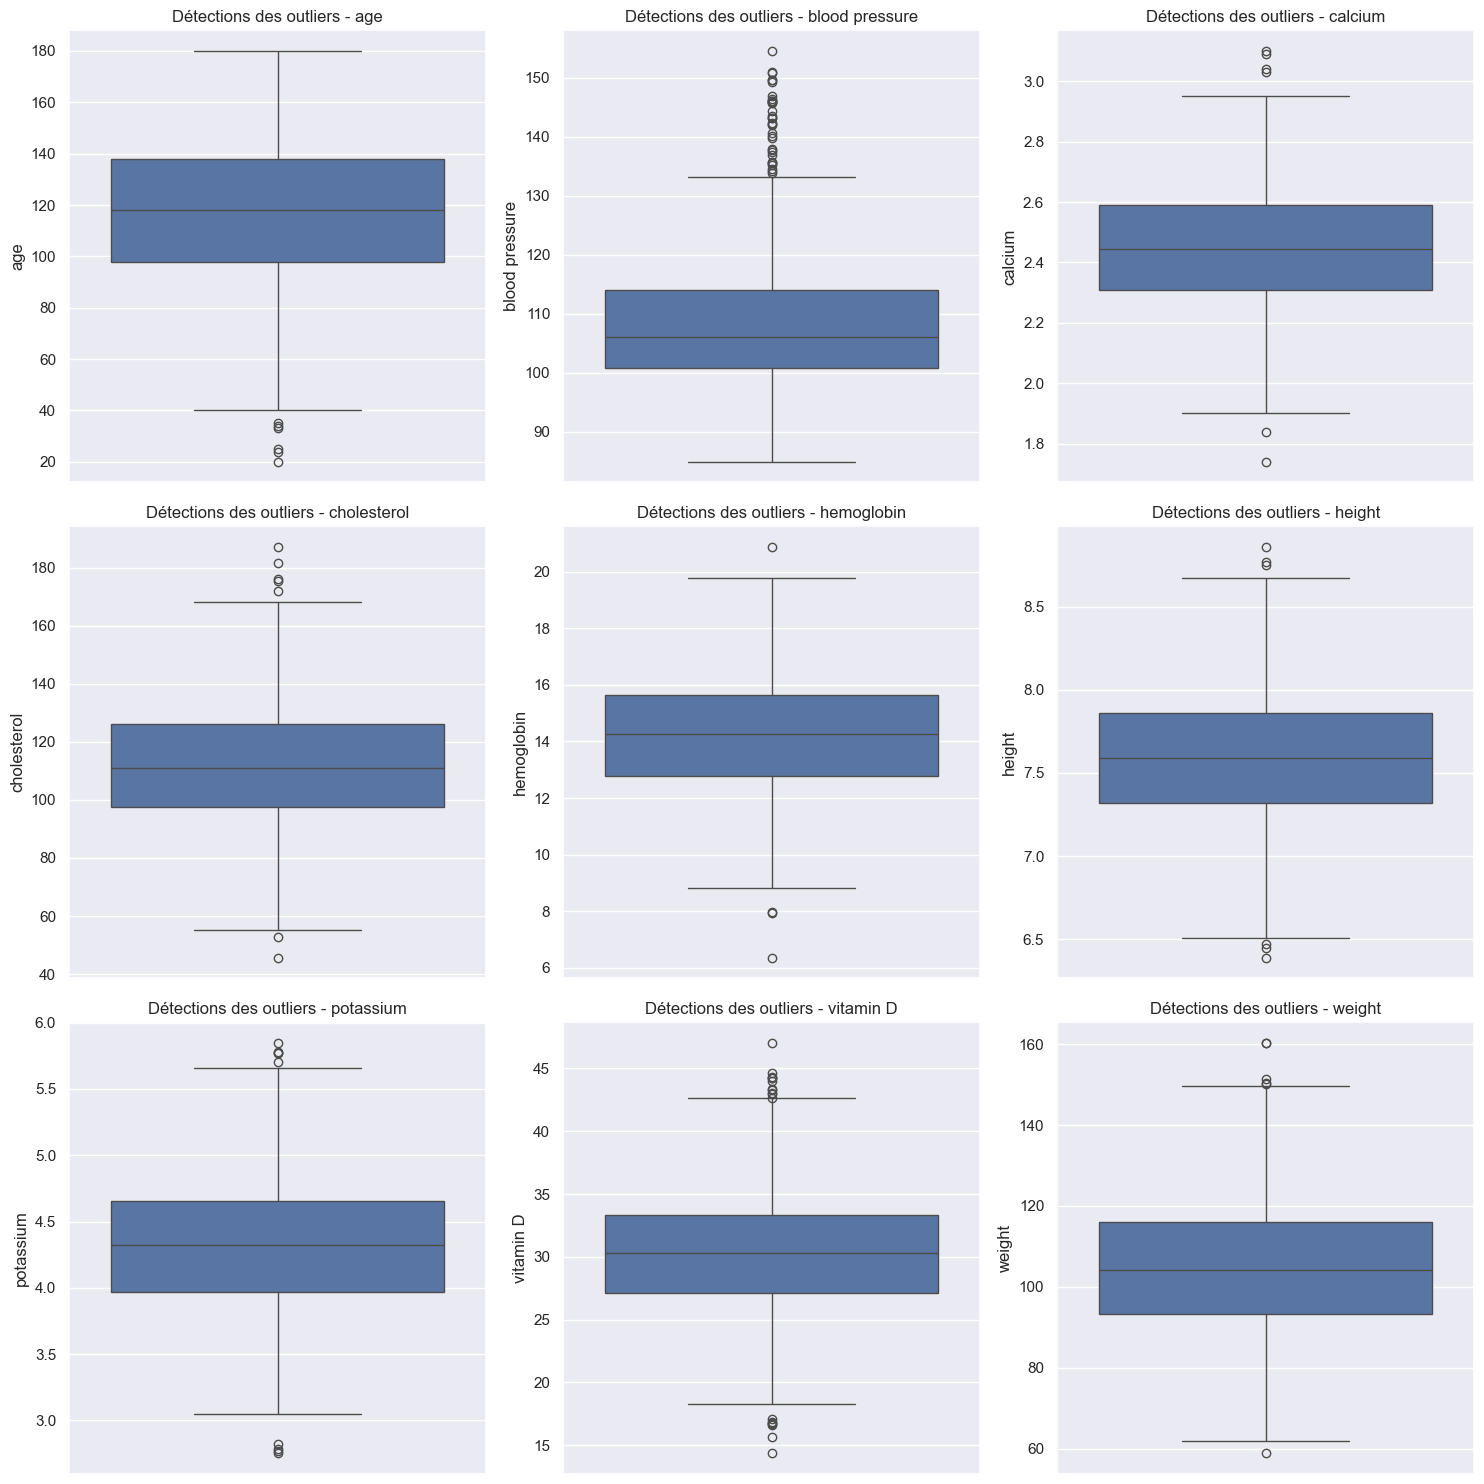

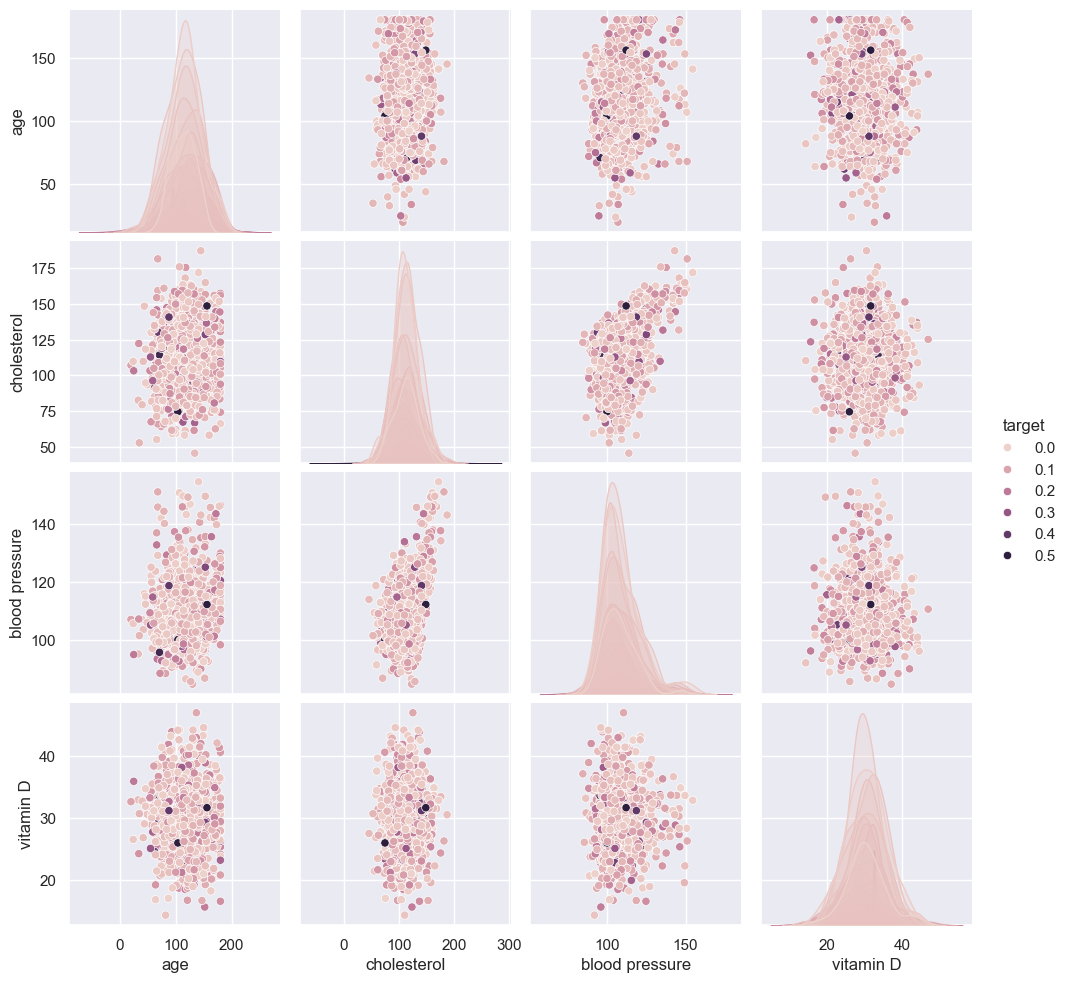

In [32]:
# valeurs manquantes ?
print(f"Valeurs manquantes : \n{X_train.isnull().sum()}")

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for i, col in enumerate(numeric_cols):
    ax = axes[i//3, i%3]
    sns.boxplot(data=X_train, y=col, ax=ax)
    ax.set_title(f'Détections des outliers - {col}')
plt.tight_layout()
plt.show()

sns.pairplot(X_train_with_target[['age', 'cholesterol', 'blood pressure','vitamin D', 'target']], 
             hue='target', diag_kind='kde')
plt.show()